# Categorizing Trends in Science using Unsupervised Learning

## Categorizing Trends in Science

In this notebook, we work on the following task:

> A company wants to position itself more towards research and academic cooperation.  
> During an early stage of this effort, the company wants to investigate what the current topics in science are  
> and for which topics an advanced academic cooperation could make sense.  
> The goal is to provide a **comprehensive quantitative overview** of current topics in science based on a large  
> archive of recently published scientific articles.

We use unsupervised learning techniques to:
- explore a large corpus of scientific articles,
- obtain a **low-dimensional representation** of the scientific landscape,
- identify **homogeneous clusters** of articles,
- interpret these clusters as **research topics**,
- and discuss **current trends** and potential areas for academic cooperation.

The notebook supports two modes:

- **FULL MODE**: uses the complete local dataset (millions of articles, large files, not suitable for GitHub).
- **DEMO MODE**: uses a small sample dataset stored in `data/`, suitable for GitHub and quick execution.

The results from FULL MODE are intended to be used for the **project report**.


In [1]:
# ============================================
# 0. ENVIRONMENT SETUP & MODE SELECTION
# ============================================

import os

# Ensure we run from project root if started from notebooks/
if os.getcwd().endswith("notebooks"):
    os.chdir("..")

print("Current working directory:", os.getcwd())

# MODE SELECTION
# "FULL" = full dataset (local machine only, large files)
# "DEMO" = small sample dataset (GitHub-friendly)
MODE = "FULL"  # change to "DEMO" before pushing to GitHub

print(f"Running in {MODE} MODE")


Current working directory: /Users/integrity/scientific_topic_clustering
Running in FULL MODE


## 1. Imports and Mode-Aware Data Loading

In this section, we:

- import all required Python libraries,
- load the **2D UMAP embeddings** of articles,
- load the **cluster labels** obtained from a clustering algorithm (e.g. HDBSCAN),
- load the **metadata** (titles, abstracts, categories, years).

The loading logic is **mode-aware**:

- In **FULL MODE**, we load the complete embeddings and labels from `outputs/`  
  and the full metadata from the original arXiv JSON snapshot.
- In **DEMO MODE**, we load small sample files from `data/`, which are lightweight and suitable for GitHub.

This separation allows us to:
- run a full, large-scale analysis locally,
- and still provide a runnable, illustrative version in the public repository.


In [2]:
# ============================================
# 1. IMPORTS & MODE-AWARE DATA LOADING
# ============================================

import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

sns.set(style="whitegrid", rc={"figure.figsize": (10, 6)})

# --------------------------------------------
# Load embeddings, labels, and metadata
# --------------------------------------------

if MODE == "FULL":
    # Full dataset (local only, not pushed to GitHub)
    print("Loading FULL dataset from outputs/ and arxiv-metadata-oai-snapshot.json ...")

    umap_emb = np.load("outputs/umap_embeddings.npy")
    labels = np.load("outputs/cluster_labels.npy")

    metadata = []
    with open("arxiv-metadata-oai-snapshot.json", "r") as f:
        for line in f:
            obj = json.loads(line)
            metadata.append({
                "title": obj.get("title", ""),
                "abstract": obj.get("abstract", ""),
                "categories": obj.get("categories", ""),
                "year": int(obj.get("update_date", "2000-01-01")[:4])
            })
    meta_df = pd.DataFrame(metadata)

else:
    # DEMO MODE: use small sample files stored in data/
    print("Running in DEMO MODE (using small sample dataset from data/)")

    # Small embeddings
    umap_emb = np.load("data/sample_embeddings.txt.npy")

    # Small labels
    labels = np.loadtxt("data/sample_cluster_labels.txt", dtype=int)

    # Small metadata
    meta_df = pd.read_json("data/sample_data.jsonl", lines=True)

print("Loaded embeddings:", umap_emb.shape)
print("Loaded labels:", labels.shape)
print("Metadata loaded:", meta_df.shape)


Loading FULL dataset from outputs/ and arxiv-metadata-oai-snapshot.json ...
Loaded embeddings: (2166782, 2)
Loaded labels: (2166782,)
Metadata loaded: (2944370, 4)


## 2. Data Exploration

Before diving into clustering results and topic interpretation,  
we first explore the available data to understand its structure and characteristics.

In this section, we:

- inspect the **number of articles**,
- analyze the **distribution of publication years**,
- look at the **most frequent arXiv categories**,
- and examine the **distribution of abstract lengths**.

This helps us assess:
- the temporal coverage of the dataset,
- the diversity of scientific fields,
- and the typical amount of textual information per article.


Number of articles: 2944370


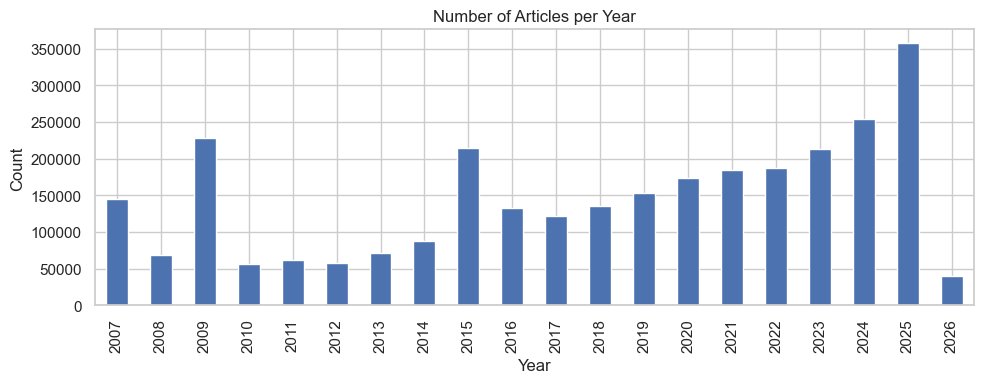

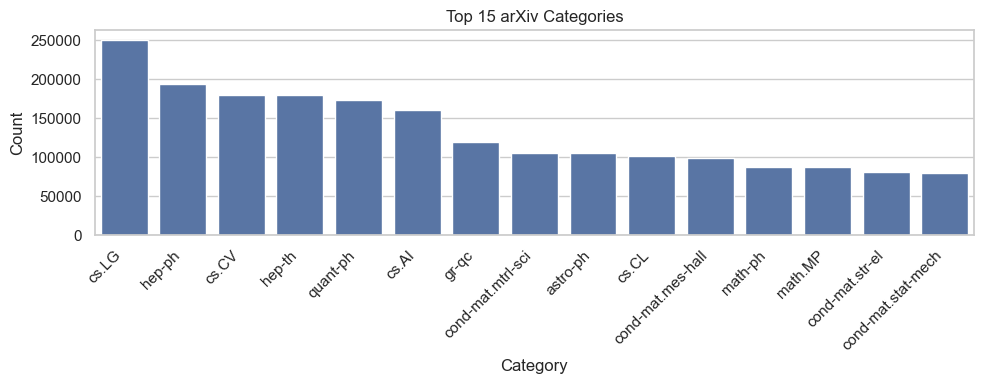

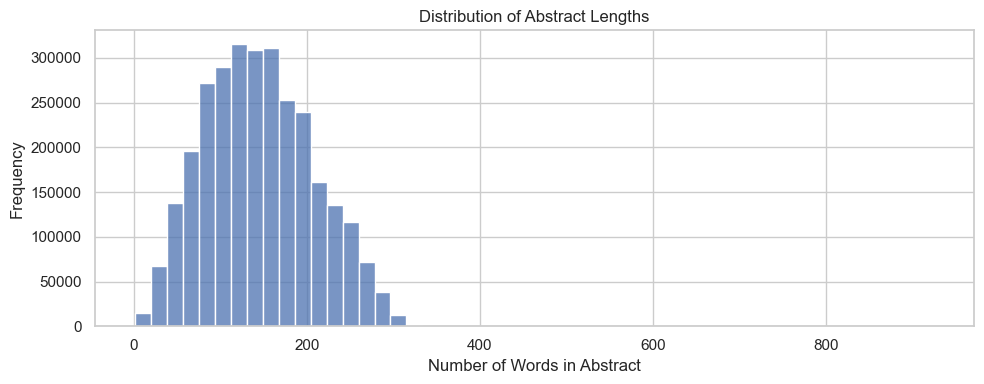

In [3]:
# ============================================
# 2. DATA EXPLORATION
# ============================================

print("Number of articles:", len(meta_df))

# Distribution of years
plt.figure(figsize=(10, 4))
meta_df["year"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of Articles per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Top 15 arXiv categories
plt.figure(figsize=(10, 4))
all_cats = " ".join(meta_df["categories"]).split()
top_cats = Counter(all_cats).most_common(15)
cats_df = pd.DataFrame(top_cats, columns=["category", "count"])

sns.barplot(data=cats_df, x="category", y="count")
plt.xticks(rotation=45, ha="right")
plt.title("Top 15 arXiv Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Text length distribution
meta_df["text_length"] = meta_df["abstract"].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10, 4))
sns.histplot(meta_df["text_length"], bins=50)
plt.title("Distribution of Abstract Lengths")
plt.xlabel("Number of Words in Abstract")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 3. Visualizing the Scientific Landscape with UMAP

To obtain an interpretable view of the high-dimensional scientific corpus,  
we use **2D UMAP embeddings** of the articles.

Each point in the 2D space represents a scientific article,  
and the color encodes the **cluster assignment** obtained from the clustering algorithm.

This visualization allows us to:
- see how articles are grouped in the embedding space,
- identify dense regions corresponding to major research areas,
- and visually assess whether clusters appear reasonably homogeneous and separated.


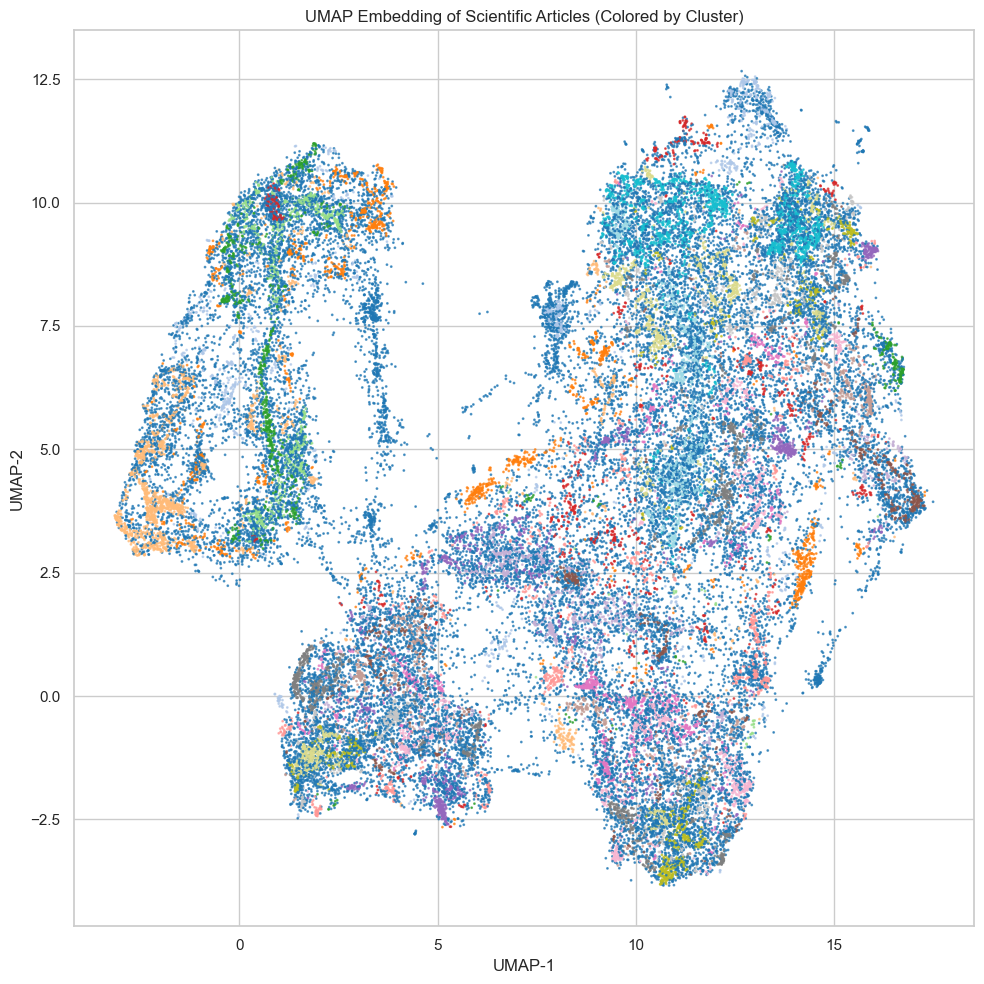

In [4]:
# ============================================
# 3. UMAP VISUALIZATION
# ============================================

# Sample for visualization to keep plots readable
N = 50000 if MODE == "FULL" else len(umap_emb)
idx = np.random.choice(len(umap_emb), min(N, len(umap_emb)), replace=False)

plt.figure(figsize=(10, 10))
plt.scatter(
    umap_emb[idx, 0],
    umap_emb[idx, 1],
    s=1,
    c=labels[idx],
    cmap="tab20",
    alpha=0.7
)
plt.title("UMAP Embedding of Scientific Articles (Colored by Cluster)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()


## 4. Cluster Size Overview

We now analyze the **sizes of the clusters** produced by the clustering algorithm.

Since density-based clustering (e.g. HDBSCAN) often produces:
- a few large clusters,
- many medium-sized clusters,
- and some very small or noisy clusters,

we focus on the **Top 20 largest clusters** (excluding noise, if present).  
These clusters typically correspond to the **dominant research topics** in the dataset.

We also inspect the size distribution to understand how research activity is distributed across topics.


In [6]:
# ============================================
# 4. CLUSTER SIZE OVERVIEW
# ============================================

cluster_ids, counts = np.unique(labels, return_counts=True)
cluster_sizes = pd.DataFrame({"cluster": cluster_ids, "size": counts})
cluster_sizes = cluster_sizes.sort_values("size", ascending=False)

# Exclude noise cluster (-1) if present
real_clusters = cluster_sizes[cluster_sizes["cluster"] != -1]

print("Number of clusters (excluding noise):", len(real_clusters))

top_n = real_clusters.head(20)
top_n


Number of clusters (excluding noise): 6756


,cluster,size
1223,1222,16826
233,232,12716
685,684,10931
4859,4858,8793
6357,6356,7921
2791,2790,7693
6161,6160,7362
5841,5840,7271
4119,4118,5850
1582,1581,5684


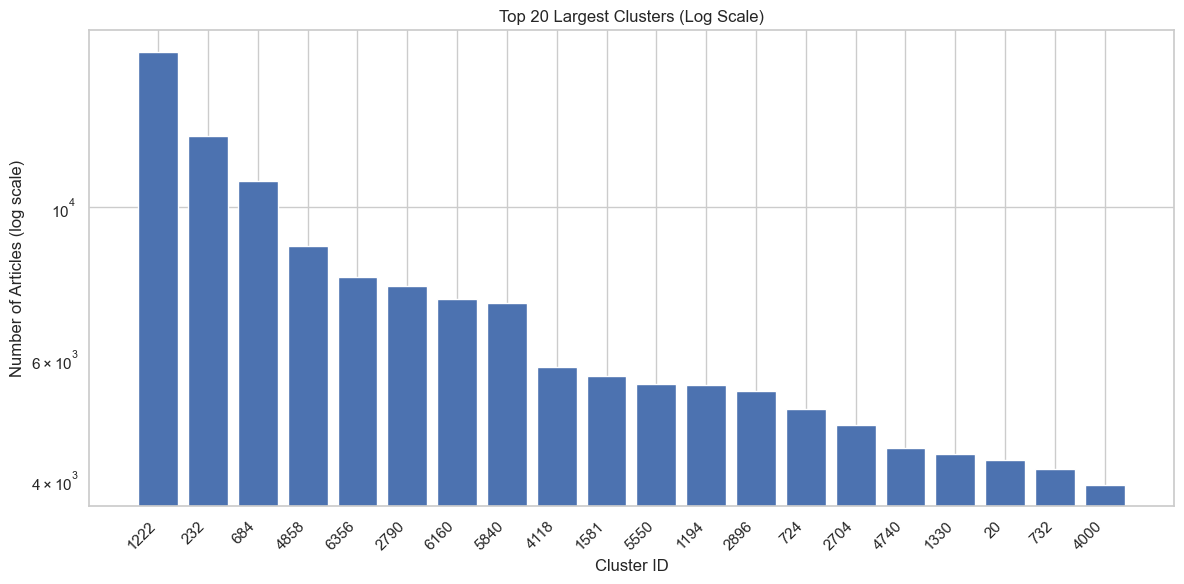

In [7]:
plt.figure(figsize=(12, 6))
plt.bar(top_n["cluster"].astype(str), top_n["size"])
plt.yscale("log")
plt.title("Top 20 Largest Clusters (Log Scale)")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Articles (log scale)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 5. Topic Interpretation

To interpret the clusters as **scientific topics**, we:

1. Sample a few **titles and abstracts** from each cluster.
2. Extract **frequent keywords** from the text of articles in a cluster.
3. Use these keywords and examples to assign **human-readable topic labels**  
   (e.g. *"Deep Learning"*, *"Quantum Information"*, *"Cosmology"*, *"Graph Neural Networks"*).

This step is crucial for:
- turning abstract clusters into meaningful topics,
- understanding what each cluster represents,
- and later discussing **trends** and **potential collaboration areas**.


In [8]:
# ============================================
# 5. TOPIC INTERPRETATION HELPERS
# ============================================

def sample_cluster_indices(cluster_id, n=10):
    idx = np.where(labels == cluster_id)[0]
    if len(idx) == 0:
        return []
    return np.random.choice(idx, min(n, len(idx)), replace=False)

def sample_cluster_texts(cluster_id, n=5):
    idx_sample = sample_cluster_indices(cluster_id, n)
    rows = meta_df.iloc[idx_sample]
    texts = []
    for _, row in rows.iterrows():
        texts.append(row["title"] + " — " + row["abstract"])
    return texts

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text

def cluster_keywords(cluster_id, n_docs=200, top_k=20):
    idx = np.where(labels == cluster_id)[0]
    idx = idx[:min(n_docs, len(idx))]
    texts = (meta_df.iloc[idx]["title"] + " " + meta_df.iloc[idx]["abstract"]).tolist()
    tokens = []
    for t in texts:
        t_clean = clean_text(t)
        tokens.extend(t_clean.split())
    stopwords = set([
        "the","and","of","in","to","a","for","on","with","we","is","are","this","that",
        "by","an","as","be","from","at","our","using","can","have","has","it","their",
        "these","they","which","or","also","into","based","within","between","such"
    ])
    tokens = [w for w in tokens if len(w) > 3 and w not in stopwords]
    counts = Counter(tokens).most_common(top_k)
    return counts


### 5.1 Inspecting Example Clusters

We now inspect a few of the largest clusters by:

- printing sample titles and abstracts,
- extracting the most frequent keywords.

This allows us to qualitatively assess whether the clusters are:

- **coherent** (articles in a cluster share a common theme),
- **distinct** (different clusters correspond to different topics),
- and **meaningful** in the context of scientific research.


In [10]:
# ============================================
# 5.1 EXAMPLE: LARGEST CLUSTER
# ============================================

largest_cluster_id = int(top_n.iloc[0]["cluster"])
print("Largest cluster ID:", largest_cluster_id)
print("Size:", int(top_n.iloc[0]["size"]))

print("\nTop keywords in largest cluster:")
for word, count in cluster_keywords(largest_cluster_id, n_docs=500, top_k=15):
    print(f"{word}: {count}")

print("\nSample titles and abstracts:")
for t in sample_cluster_texts(largest_cluster_id, n=3):
    print("-" * 80)
    print(t[:1000])  # truncate for readability


Largest cluster ID: 1222
Size: 16826

Top keywords in largest cluster:
model: 206
results: 151
show: 151
field: 150
quantum: 143
theory: 142
mass: 135
systems: 120
study: 115
state: 109
time: 108
energy: 108
function: 107
system: 105
spin: 102

Sample titles and abstracts:
--------------------------------------------------------------------------------
Joint RFI Mitigation and Radar Echo Recovery for One-Bit UWB Radar —   Radio frequency interference (RFI) mitigation and radar echo recovery are
critically important for the proper functioning of ultra-wideband (UWB) radar
systems using one-bit sampling techniques. We recently introduced a technique
for one-bit UWB radar, which first uses a majorization-minimization method for
RFI parameter estimation followed by a sparse method for radar echo recovery.
However, this technique suffers from high computational complexity due to the
need to estimate the parameters of each RFI source separately and iteratively.
In this paper, we present a co

In [11]:
# ============================================
# 5.2 SUMMARY TABLE OF TOP CLUSTERS
# ============================================

topic_summaries = []

for _, row in top_n.iterrows():
    cid = int(row["cluster"])
    size = int(row["size"])
    kw = cluster_keywords(cid, n_docs=500, top_k=10)
    topic_summaries.append({
        "cluster_id": cid,
        "size": size,
        "keywords": ", ".join([w for w, _ in kw])
    })

topics_df = pd.DataFrame(topic_summaries).sort_values("size", ascending=False)
topics_df


,cluster_id,size,keywords
0,1222,16826,"model, results, show, field, quantum, theory, ..."
1,232,12716,"model, quantum, show, results, time, field, en..."
2,684,10931,"model, field, quantum, energy, results, mass, ..."
3,4858,8793,"model, field, show, results, theory, energy, m..."
4,6356,7921,"model, show, field, energy, results, time, dat..."
5,2790,7693,"model, field, theory, show, energy, time, resu..."
6,6160,7362,"model, show, results, data, spin, quantum, ene..."
7,5840,7271,"model, field, show, results, study, energy, sp..."
8,4118,5850,"model, field, results, theory, show, energy, q..."
9,1581,5684,"model, energy, field, show, quantum, results, ..."


## 6. Trend Analysis and Strategic Interpretation

Based on the cluster sizes and extracted keywords, we can now:

- identify **dominant research areas** (large clusters with clear thematic focus),
- detect **emerging or niche topics** (smaller but coherent clusters),
- and discuss **potential areas for academic cooperation**.

In the context of the company’s strategic objective, we can:

- prioritize collaboration in **large, rapidly evolving fields** (e.g. deep learning, quantum computing),
- consider **specialized partnerships** in niche but high-impact areas,
- and use the topic overview as a **map of the scientific landscape** to guide long-term decisions.


In [12]:
# ============================================
# 6. TREND-ORIENTED VIEW
# ============================================

# Here we simply display the top topics again, sorted by size.
# In a more advanced analysis, we could also incorporate time (year) to see temporal trends.

topics_df.reset_index(drop=True)


,cluster_id,size,keywords
0,1222,16826,"model, results, show, field, quantum, theory, ..."
1,232,12716,"model, quantum, show, results, time, field, en..."
2,684,10931,"model, field, quantum, energy, results, mass, ..."
3,4858,8793,"model, field, show, results, theory, energy, m..."
4,6356,7921,"model, show, field, energy, results, time, dat..."
5,2790,7693,"model, field, theory, show, energy, time, resu..."
6,6160,7362,"model, show, results, data, spin, quantum, ene..."
7,5840,7271,"model, field, show, results, study, energy, sp..."
8,4118,5850,"model, field, results, theory, show, energy, q..."
9,1581,5684,"model, energy, field, show, quantum, results, ..."


## 7. Critical Reflection and Limitations

There is no single "perfect" solution to this task.  
Important aspects to critically reflect on:

- **Data preprocessing**:  
  The quality of embeddings and clusters depends heavily on how text was cleaned, tokenized, and embedded.
- **Choice of dimensionality reduction**:  
  UMAP is powerful but has hyperparameters that influence the structure of the embedding.
- **Clustering algorithm**:  
  Density-based methods (e.g. HDBSCAN) can handle complex shapes and noise,  
  but the choice of parameters affects the number and size of clusters.
- **Interpretability**:  
  Topic interpretation relies on keyword extraction and manual inspection,  
  which introduces a subjective component.
- **Temporal trends**:  
  A more advanced analysis could explicitly model how topic prevalence changes over time.

Despite these limitations, the approach provides:

- a **quantitative overview** of current topics in science,
- a **low-dimensional visualization** of the scientific landscape,
- and a **cluster-based topic structure** that can guide strategic academic cooperation.

These results can now be used as the basis for the **project report**,  
where the methodology, decisions, and interpretations are discussed in more detail.
